In [1]:
# ============================================================
# Import Libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import matthews_corrcoef

from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV

from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")

In [3]:
# ============================================================
# Load Dataset
# ============================================================
df = pd.read_csv("creditcard.csv")
print("Initial Dataset Shape:", df.shape)

Initial Dataset Shape: (284807, 31)


In [4]:
# Dataset Information
print("\nDataset Information")
df.info()

print("\nDataset Description")
print(df.describe())


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  fl

In [5]:
# ============================================================
# Missing Values Check
# ============================================================
total_null = df.isnull().sum().sum()

if total_null == 0:
    print("No missing values found.")
else:
    print("Total missing values:", total_null)

No missing values found.


In [6]:
# ============================================================
# Duplicate Removal
# ============================================================
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

if duplicates > 0:
    df = df.drop_duplicates()

print("Dataset Shape After Duplicate Removal:", df.shape)

Duplicate Rows: 1081
Dataset Shape After Duplicate Removal: (283726, 31)


Class
0    283253
1       473
Name: count, dtype: int64


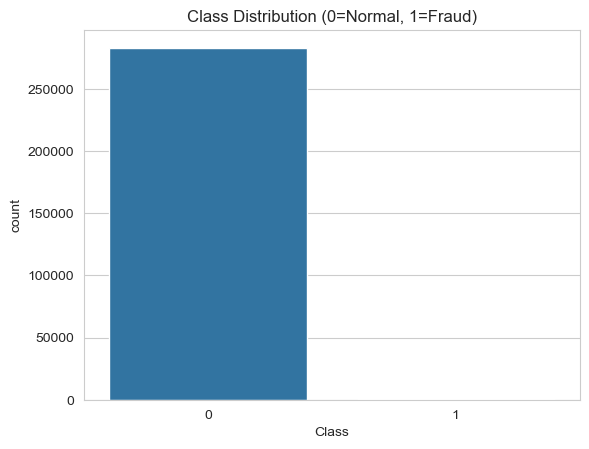

In [7]:
# ============================================================
# Class Distribution
# ============================================================
print(df["Class"].value_counts())

plt.figure()
sns.countplot(x="Class", data=df)
plt.title("Class Distribution (0=Normal, 1=Fraud)")
plt.show()

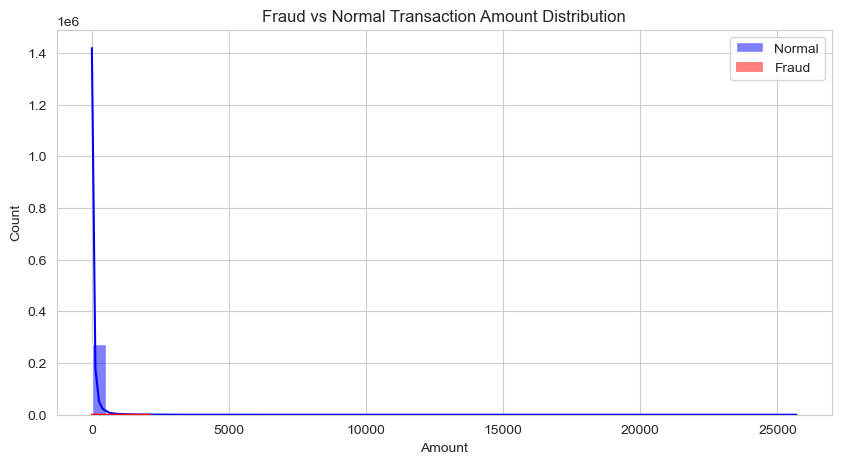

In [8]:
# ============================================================
# Fraud vs Normal Transaction Amount Distribution
# ============================================================
plt.figure(figsize=(10,5))

sns.histplot(df[df["Class"]==0]["Amount"], bins=50, color="blue", label="Normal", kde=True)
sns.histplot(df[df["Class"]==1]["Amount"], bins=50, color="red", label="Fraud", kde=True)

plt.legend()
plt.title("Fraud vs Normal Transaction Amount Distribution")
plt.show()

In [9]:
# ============================================================
# Feature Scaling
# ============================================================
scaler = StandardScaler()

df["Amount"] = scaler.fit_transform(df[["Amount"]])
df["Time"] = scaler.fit_transform(df[["Time"]])

In [10]:
# ============================================================
# Feature Selection
# ============================================================
X = df.drop("Class", axis=1)
y = df["Class"]

In [11]:
# ============================================================
# Train Test Split
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Training Shape: (226980, 30)
Test Shape: (56746, 30)


Training Shape After SMOTE: (453204, 30)


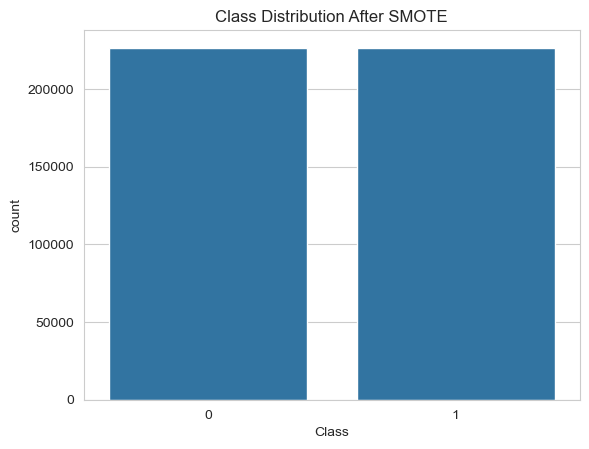

In [12]:
# ============================================================
# Apply SMOTE
# ============================================================
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Training Shape After SMOTE:", X_train_smote.shape)

plt.figure()
sns.countplot(x=y_train_smote)
plt.title("Class Distribution After SMOTE")
plt.show()